# 02 — Constraint Analysis & Peer Benchmarking
**DataStorm v7.0 | SkyNet Team**

## Problem Context
Historical volume is **censored** — it represents `min(true_demand, systemic_constraints)`.  
There is **no target variable (y)**. We must build a defensible framework to uncap latent demand.

## This Notebook
The gold enrichment pipeline (`03_gold_enrichment.py`) has already:
1. Classified every outlet into a constraint archetype
2. Computed peer-group 90th-percentile benchmarks
3. Assigned constraint multipliers for the two-stage uncapping model

This notebook **validates and visualises** those classifications to ensure they are defensible,
then saves the data for the modeling notebook.

### Constraint Types
| Type | Signal | Multiplier |
|------|--------|------------|
| Genuinely_Low_Demand | Stable, low volume, no constraint signals | 1.00 |
| Moderately_Constrained | Some suppression but no clear single signal | 1.10 |
| Delivery_Capped | High peak-to-average ratio, high variability | 1.15 |
| Credit_Constrained | Repeatedly ordering near the same ceiling | 1.25 |
| Stockout_Constrained | Zero-volume months within active window | 1.35 |

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

GOLD_DIR = ROOT / 'data' / 'gold'
REPORTS  = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
print('Setup complete')

Setup complete


## 1. Load Gold-Enriched Data
This file already contains constraint classifications, peer benchmarks, and all engineered features from the pipeline.

In [9]:
df = pd.read_csv(GOLD_DIR / 'model_input_final.csv')
print('Data loaded:', df.shape)
print('\nColumns:', list(df.columns))

Data loaded: (19804, 76)

Columns: ['Outlet_ID', 'mean_monthly_volume', 'median_monthly_volume', 'max_monthly_volume', 'std_monthly_volume', 'cv_volume', 'months_active', 'total_volume', 'total_value', 'zero_order_months', 'order_frequency', 'peak_to_avg_ratio', 'dominant_distributor', 'credit_limit_hit_rate', 'stockout_flag', 'volume_trend', 'jan_mean_volume', 'jan_max_volume', 'jan_min_volume', 'jan_data_points', 'jan_yoy_2023_2024', 'jan_yoy_2024_2025', 'sku_growth', 'max_annual_sku_count', 'Cooler_Count', 'outlet_size_ord', 'price_per_liter', 'Latitude', 'Longitude', 'peer_group', 'peer_90th_potential', 'peer_75th_potential', 'peer_group_size', 'peer_percentile_rank', 'uncapping_factor', 'constraint_type', 'constraint_multiplier', 'jan26_seasonality_index', 'jan_total_holidays', 'jan_poya_days', 'jan_public_holidays', 'poi_schools', 'poi_universities', 'poi_bus_stops', 'poi_hospitals', 'poi_clinics', 'poi_hotels', 'poi_guesthouses', 'poi_markets', 'poi_supermarkets', 'poi_places_of

## 2. Constraint Distribution
The gold enrichment pipeline classifies each outlet using data-driven thresholds.  
We expect a realistic distribution with a meaningful number of Genuinely_Low_Demand outlets.

Constraint Distribution:
constraint_type
Moderately_Constrained    12139
Delivery_Capped            7665
Name: count, dtype: int64

Percentage:
constraint_type
Moderately_Constrained    61.3
Delivery_Capped           38.7
Name: proportion, dtype: float64


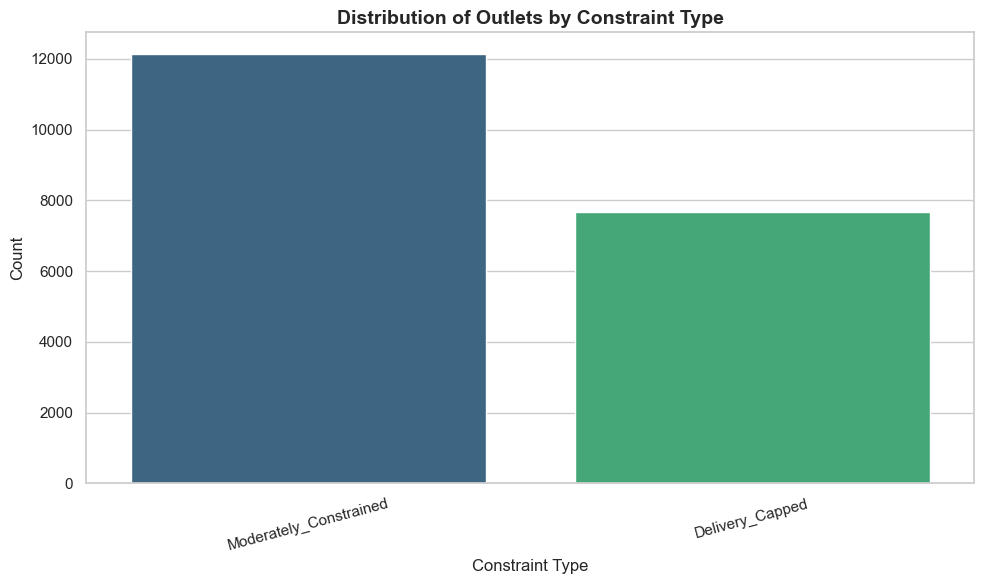

In [10]:
print('Constraint Distribution:')
print(df['constraint_type'].value_counts())
print('\nPercentage:')
print(df['constraint_type'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(10, 6))
order = df['constraint_type'].value_counts().index
sns.countplot(data=df, x='constraint_type', order=order, hue='constraint_type',
              palette='viridis', legend=False)
plt.title('Distribution of Outlets by Constraint Type', fontsize=14, fontweight='bold')
plt.xlabel('Constraint Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(REPORTS / 'constraint_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Constraint Analysis — Volume Profiles by Type
Each constraint type should exhibit a distinct volume pattern. This validates the classification logic.

Constraint Type Profiles:
                       mean_monthly_volume         max_monthly_volume          \
                                      mean  median               mean  median   
constraint_type                                                                 
Delivery_Capped                      49.73   40.76             145.05  123.37   
Moderately_Constrained              316.75  143.58             544.18  307.20   

                       cv_volume        credit_limit_hit_rate         \
                            mean median                  mean median   
constraint_type                                                        
Delivery_Capped             0.83   0.83                  0.06   0.06   
Moderately_Constrained      0.51   0.53                  0.07   0.06   

                       stockout_flag        peak_to_avg_ratio         \
                                mean median              mean median   
constraint_type                                                

C:\Users\User\AppData\Local\Temp\ipykernel_21380\603576081.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=15, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_21380\603576081.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=15, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_21380\603576081.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_21380\603576081.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

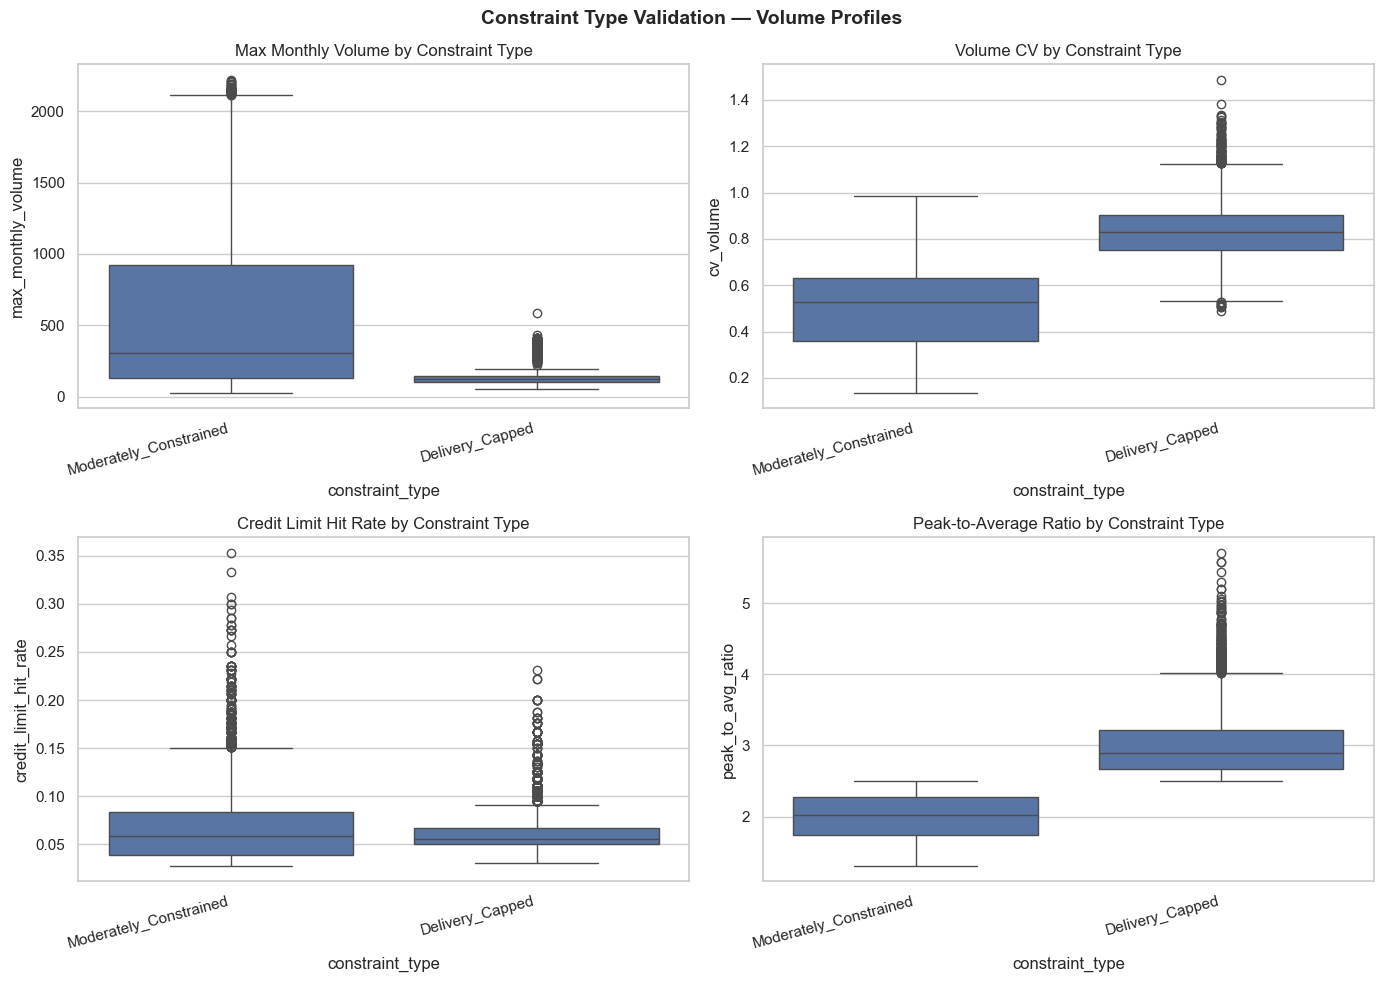

In [11]:
# Key metrics by constraint type
analysis_cols = ['mean_monthly_volume', 'max_monthly_volume', 'cv_volume',
                 'credit_limit_hit_rate', 'stockout_flag', 'peak_to_avg_ratio',
                 'zero_order_months', 'months_active', 'constraint_multiplier']

constraint_profiles = df.groupby('constraint_type')[analysis_cols].agg(['mean', 'median']).round(2)
print('Constraint Type Profiles:')
print(constraint_profiles)

# Volume distribution by constraint type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='constraint_type', y='max_monthly_volume', ax=axes[0, 0])
axes[0, 0].set_title('Max Monthly Volume by Constraint Type')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=15, ha='right')

sns.boxplot(data=df, x='constraint_type', y='cv_volume', ax=axes[0, 1])
axes[0, 1].set_title('Volume CV by Constraint Type')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=15, ha='right')

sns.boxplot(data=df, x='constraint_type', y='credit_limit_hit_rate', ax=axes[1, 0])
axes[1, 0].set_title('Credit Limit Hit Rate by Constraint Type')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15, ha='right')

sns.boxplot(data=df, x='constraint_type', y='peak_to_avg_ratio', ax=axes[1, 1])
axes[1, 1].set_title('Peak-to-Average Ratio by Constraint Type')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Constraint Type Validation — Volume Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'constraint_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Peer Group Benchmarking Analysis
The 90th percentile of `max_monthly_volume` within each peer group (Type × Province × Size) represents the empirical ceiling — what a similar, unconstrained outlet actually sells.

Unique peer groups: 144

Uncapping Factor Statistics:
count    19804.000
mean         1.242
std          0.244
min          1.000
25%          1.055
50%          1.167
75%          1.370
max          3.000
Name: uncapping_factor, dtype: float64

Peer 90th Percentile Statistics:
count    19804.00
mean       423.64
std        472.34
min        135.14
25%        147.04
50%        151.06
75%        361.09
max       2213.45
Name: peer_90th_potential, dtype: float64


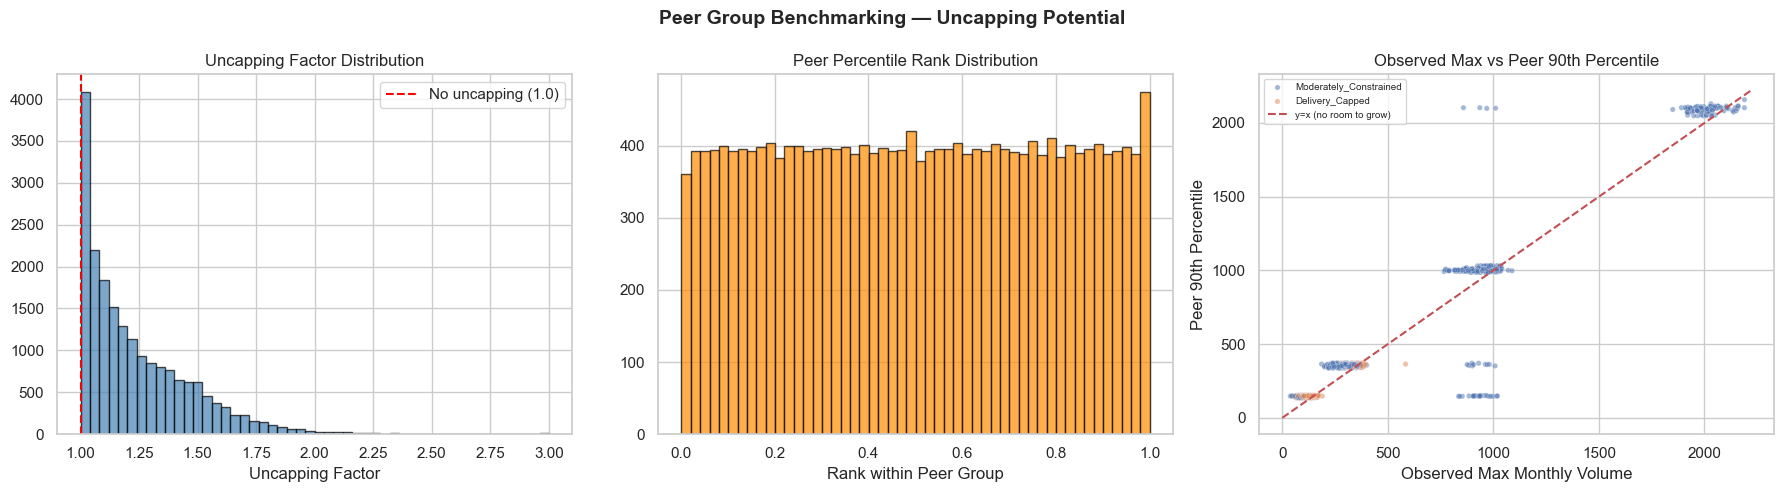

In [12]:
print(f"Unique peer groups: {df['peer_group'].nunique()}")
print(f"\nUncapping Factor Statistics:")
print(df['uncapping_factor'].describe().round(3))

print(f"\nPeer 90th Percentile Statistics:")
print(df['peer_90th_potential'].describe().round(2))

# Peer percentile rank distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['uncapping_factor'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Uncapping Factor Distribution')
axes[0].set_xlabel('Uncapping Factor')
axes[0].axvline(1.0, color='red', linestyle='--', label='No uncapping (1.0)')
axes[0].legend()

axes[1].hist(df['peer_percentile_rank'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_title('Peer Percentile Rank Distribution')
axes[1].set_xlabel('Rank within Peer Group')

sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42),
                x='max_monthly_volume', y='peer_90th_potential',
                hue='constraint_type', alpha=0.5, ax=axes[2], s=15)
axes[2].plot([0, df['max_monthly_volume'].max()], [0, df['max_monthly_volume'].max()],
             'r--', label='y=x (no room to grow)')
axes[2].set_title('Observed Max vs Peer 90th Percentile')
axes[2].set_xlabel('Observed Max Monthly Volume')
axes[2].set_ylabel('Peer 90th Percentile')
axes[2].legend(fontsize=7)

plt.suptitle('Peer Group Benchmarking — Uncapping Potential', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'peer_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Mean vs Max Correlation (Censoring Evidence)
If `mean ≈ max` for most outlets, it means they are hitting the same ceiling every month — strong evidence of systemic constraints across the board.

Correlation between mean and max monthly volume: 0.9934
This near-perfect correlation is strong evidence of systemic demand censoring.


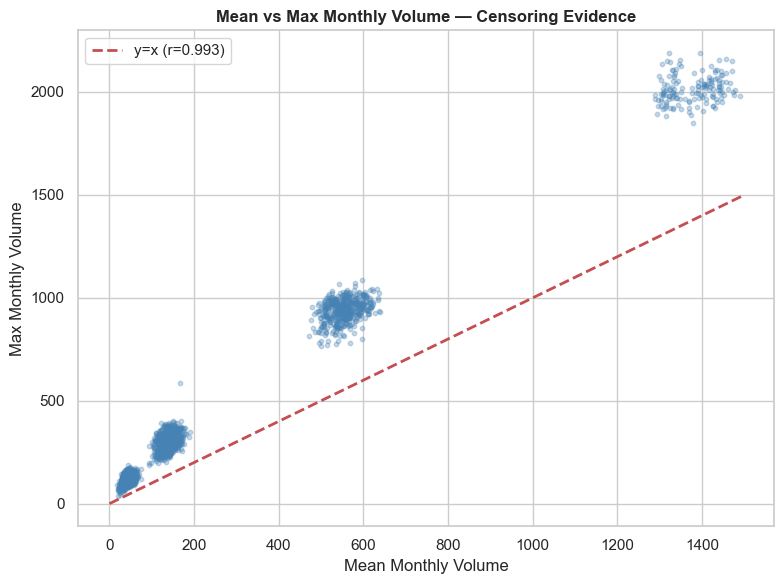

In [13]:
corr_val = df['mean_monthly_volume'].corr(df['max_monthly_volume'])
print(f'Correlation between mean and max monthly volume: {corr_val:.4f}')
print('This near-perfect correlation is strong evidence of systemic demand censoring.')

plt.figure(figsize=(8, 6))
sample = df.sample(min(3000, len(df)), random_state=42)
plt.scatter(sample['mean_monthly_volume'], sample['max_monthly_volume'],
            alpha=0.3, s=10, c='steelblue')
plt.plot([0, df['mean_monthly_volume'].max()], [0, df['mean_monthly_volume'].max()],
         'r--', label=f'y=x (r={corr_val:.3f})', linewidth=2)
plt.xlabel('Mean Monthly Volume')
plt.ylabel('Max Monthly Volume')
plt.title('Mean vs Max Monthly Volume — Censoring Evidence', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'censoring_evidence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Enriched Data for Modeling
The gold data already contains all constraint classifications, peer benchmarks, and multipliers.  
We save it with the additional analysis columns for the modeling notebook.

In [14]:
# Save for modeling notebook (same as model_input_final but confirms analysis is done)
output_path = GOLD_DIR / 'outlet_features_with_constraints.csv'
df.to_csv(output_path, index=False)
print(f'Saved constraint-enriched features: {output_path}')
print(f'Total outlets: {len(df)}')
print(f'Total features: {len(df.columns)}')
print(f'\nConstraint multiplier stats:')
print(df['constraint_multiplier'].describe())

Saved constraint-enriched features: C:\Users\User\Documents\Projects\Datastorm\SkyNet-datastorm-v7\data\gold\outlet_features_with_constraints.csv
Total outlets: 19804
Total features: 76

Constraint multiplier stats:
count    19804.000000
mean         1.119352
std          0.024354
min          1.100000
25%          1.100000
50%          1.100000
75%          1.150000
max          1.150000
Name: constraint_multiplier, dtype: float64
